# Part III — Functions and Mathematical Modeling
## Chapters 51–90

> **The mental shift:** In Parts I and II you worked with *numbers* — isolated values, sequences, arithmetic structures. In Part III, you start working with *relationships between numbers*. A function is a machine that transforms input into output, deterministically, with structure you can analyze, compose, invert, and fit to data. This is where mathematics becomes a modeling language.

---

## 1. What This Part Covers

Part III builds the concept of a **function** from the ground up, then expands it into a full toolkit for modeling real-world phenomena.

The arc:
- **Chapters 51–57**: What functions are, how to represent them, how to work with them in Python
- **Chapters 58–64**: The major function families — linear, quadratic, polynomial, rational, piecewise, step, sigmoid
- **Chapters 65–70**: How functions transform, shift, scale, and belong to parameterized families
- **Chapters 71–78**: Modeling — fitting, error, iteration, recursion, dynamical systems
- **Chapters 79–90**: Projects — 11 complete applied systems built from the concepts above

---

## 2. Why This Part Matters

Every model in machine learning, every simulation in science, every formula in engineering is a function. Understanding functions at a deep level — not just "f(x) = ..." but *what it means to map, compose, invert, and fit* — is the foundation for everything that follows.

Without this Part:
- Linear regression is a formula you copy. With it: it's a parameterized function you minimize.
- Neural activation functions are black boxes. With it: they're sigmoid/ReLU with understood behavior.
- Gradient descent is a recipe. With it: it's an iterative function application on an error landscape.

**Functions are the grammar of quantitative modeling.**

---

## 3. Prerequisites from Prior Parts

Before starting Part III, you need:

- **From Part I**: Mathematical notation (ch009), abstraction (ch003), the idea of a model (ch017–018)
- **From Part II**: Real numbers and their properties (ch026), exponential and logarithmic behavior (ch041–045), floating-point precision (ch038), the concept of growth rates (ch046–048)
- **Python**: You must be comfortable writing functions, loops, and using NumPy arrays. Plotting with matplotlib is assumed.

---

## 4. Part Map — What Connects to What

```
ch051 What is a Function?
    └── ch052 Functions as Programs
        └── ch053 Domain and Range
            ├── ch054 Function Composition
            └── ch055 Inverse Functions
                └── ch056 Visualizing Functions
                    └── ch057 Graphing Functions with Python

ch058 Linear Functions ──────────────────────────────────────┐
ch059 Quadratic Functions ───────────────────────────────────┤
ch060 Polynomial Functions ──────────────────────────────────┤
ch061 Rational Functions ────────────────────────────────────┤ Function
ch062 Piecewise Functions ───────────────────────────────────┤ Families
ch063 Step Functions ────────────────────────────────────────┤
ch064 Sigmoid Functions ─────────────────────────────────────┤
ch065 Activation Functions in ML ────────────────────────────┘

ch066 Function Transformations
    ├── ch067 Scaling and Shifting
    ├── ch068 Reflection and Rotation
    ├── ch069 Parameter Sensitivity
    └── ch070 Function Families

ch071 Modeling Real Phenomena
    ├── ch072 Fitting Simple Models
    ├── ch073 Error and Residuals
    ├── ch074 Iterative Computation
    ├── ch075 Recursion and Mathematical Functions
    ├── ch076 Discrete Dynamical Systems
    ├── ch077 Chaos and Sensitivity
    ├── ch078 Simulation vs Analytical Solutions
    └── ch079 Numerical Experiments

ch080–090: Projects (11 applied systems)
```

---

## 5. Motivating Problem — You Cannot Solve This Yet

Here is a problem you will be able to fully solve by the end of Part III.

**The problem:** A disease is spreading through a city. You have daily case count data for 60 days. You want to:
1. Fit a mathematical model to the data
2. Identify when the peak occurred
3. Predict what happens after day 60
4. Estimate how sensitive the forecast is to the model parameters

Run the cell below. You will see the data. You do not yet have the tools to model it.

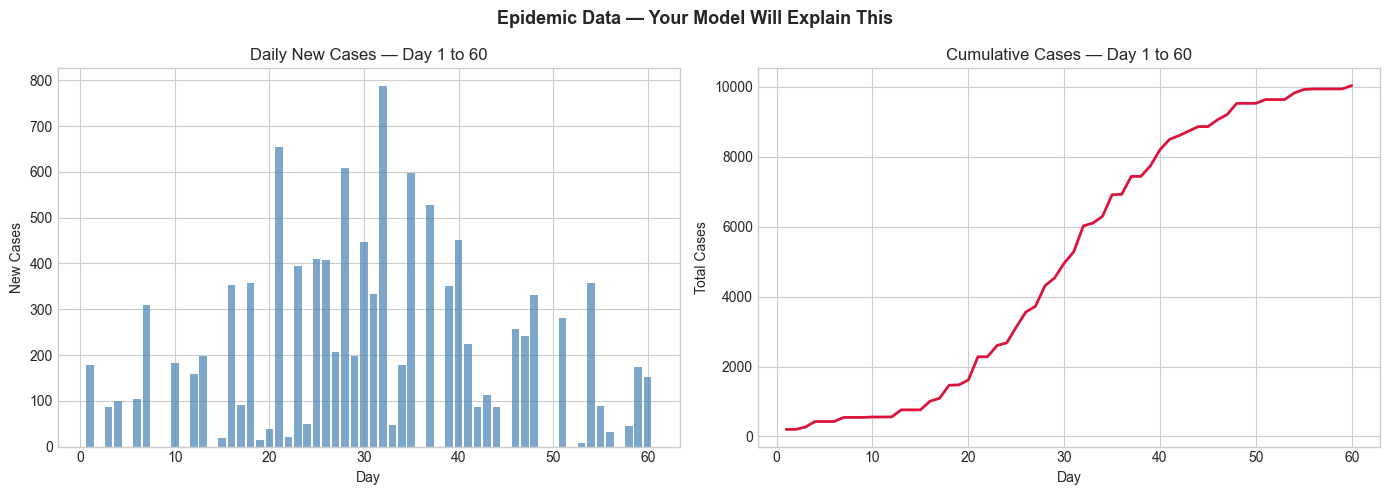

Questions you will answer by Chapter 81:
  1. What function family describes this curve?
  2. What parameters control peak timing and height?
  3. How do you fit this to observed data?
  4. How sensitive is the forecast to small parameter changes?


In [1]:
# --- Motivating Problem: Epidemic Curve ---
# This is real epidemic-shaped data. Your goal by end of Part III:
# fit a model, find the peak, and project forward.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
days = np.arange(1, 61)

# Logistic growth model + noise (you don't know this yet)
def true_model(t, K=10000, r=0.15, t0=30):
    return K / (1 + np.exp(-r * (t - t0)))

# Generate noisy observations
noise = np.random.normal(0, 150, size=len(days))
cumulative_cases = true_model(days) + noise
daily_new_cases = np.diff(np.maximum(0, cumulative_cases), prepend=0)
daily_new_cases = np.maximum(0, daily_new_cases + np.random.normal(0, 50, size=len(days)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(days, daily_new_cases, color='steelblue', alpha=0.7)
axes[0].set_title('Daily New Cases — Day 1 to 60')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('New Cases')

axes[1].plot(days, np.maximum.accumulate(cumulative_cases), color='crimson', linewidth=2)
axes[1].set_title('Cumulative Cases — Day 1 to 60')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Total Cases')

plt.suptitle('Epidemic Data — Your Model Will Explain This', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Questions you will answer by Chapter 81:")
print("  1. What function family describes this curve?")
print("  2. What parameters control peak timing and height?")
print("  3. How do you fit this to observed data?")
print("  4. How sensitive is the forecast to small parameter changes?")

---

## 6. What You Will Build in This Part

By Chapter 90, you will have implemented:

| Project | Chapter | Core Concept |
|---|---|---|
| Function Visualization Tool | ch080 | Domain, range, families |
| Epidemic Simulation | ch081 | Logistic growth, sigmoid |
| Predator–Prey Model | ch082 | Discrete dynamical systems |
| Financial Growth Model | ch083 | Exponential + logistic |
| Logistic Growth Simulation | ch084 | Iterative computation |
| Function Approximation | ch085 | Error, residuals |
| Curve Fitting | ch086 | Least squares, iteration |
| Interactive Graph Explorer | ch087 | Parameter sensitivity |
| Modeling Traffic Flow | ch088 | Piecewise + dynamical |
| Cellular Automata | ch089 | Discrete iteration, rules |
| Chaos Simulator | ch090 | Chaos, sensitivity |

---

**Begin with ch051 — What is a Function?**